In [1]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For splitting
from sklearn.model_selection import train_test_split

# For scaling
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
df = pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [7]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [9]:
df.shape

(30, 3)

In [11]:
df.isnull().sum()


Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [13]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


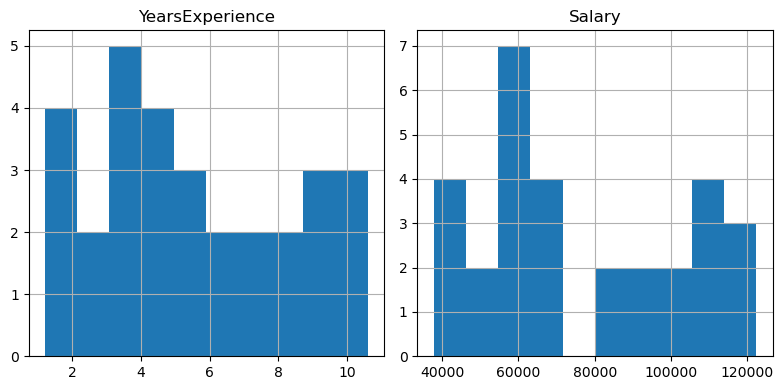

In [15]:
df.hist(figsize=(8, 4))
plt.tight_layout()
plt.show()


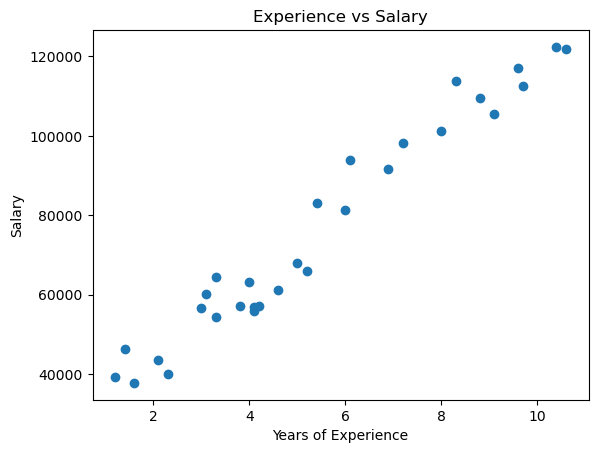

In [17]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()


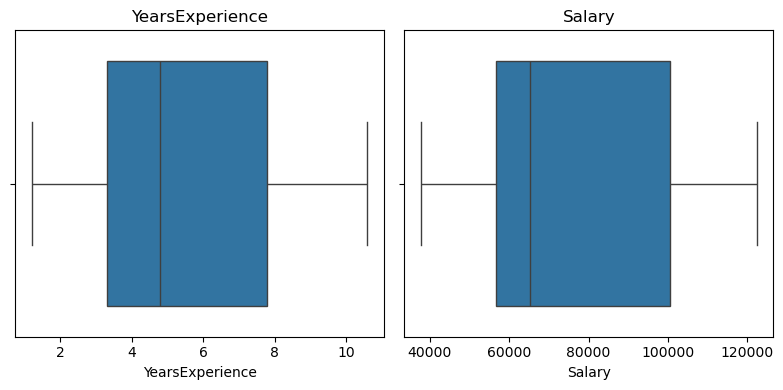

In [19]:
plt.figure(figsize=(8, 4))

for i, col in enumerate(df.select_dtypes(include=['float64', 'int64']).columns, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [21]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    print(f"{col}: {len(outliers)} outliers")


YearsExperience: 0 outliers
Salary: 0 outliers


In [23]:
# Scaling the feature column only
scaler = StandardScaler()

df["YearsExperience"] = scaler.fit_transform(df[["YearsExperience"]])

df.head()


,YearsExperience,Salary
0,-1.510053,39344.0
1,-1.438373,46206.0
2,-1.366693,37732.0
3,-1.187494,43526.0
4,-1.115814,39892.0


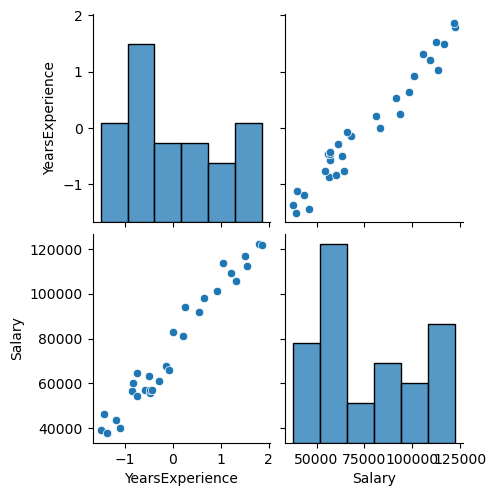

In [25]:
sns.pairplot(df)
plt.show()


In [27]:
corr_matrix = df.corr()
corr_matrix


,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


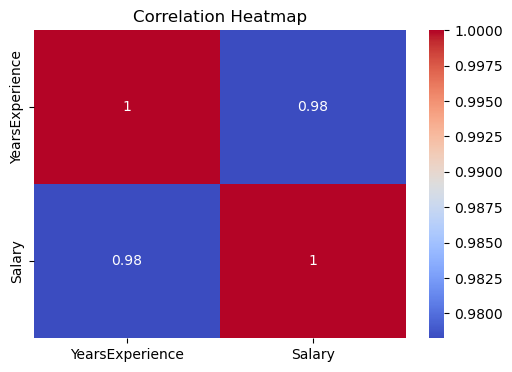

In [29]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [31]:
X = df[["YearsExperience"]]
y = df["Salary"]


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [35]:
lin_reg = LinearRegression()


In [37]:
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X)

# Split polynomial data
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_reg = LinearRegression()


In [39]:
lin_reg.fit(X_train, y_train)


LinearRegression()

In [41]:
poly_reg.fit(X_poly_train, y_poly_train)


LinearRegression()

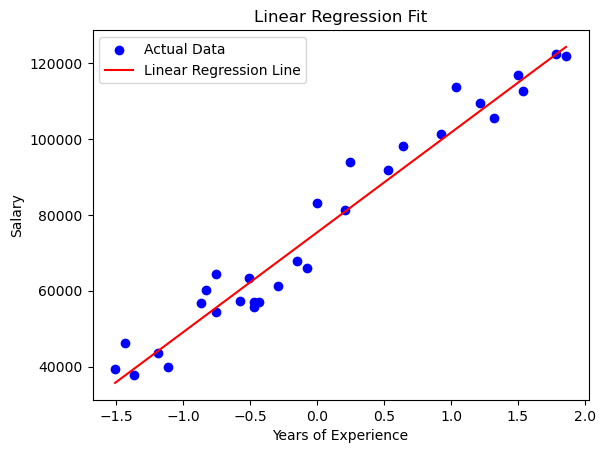

In [43]:
# Predictions for linear regression
y_pred_lin = lin_reg.predict(X)

# Plot
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, y_pred_lin, color='red', label="Linear Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()


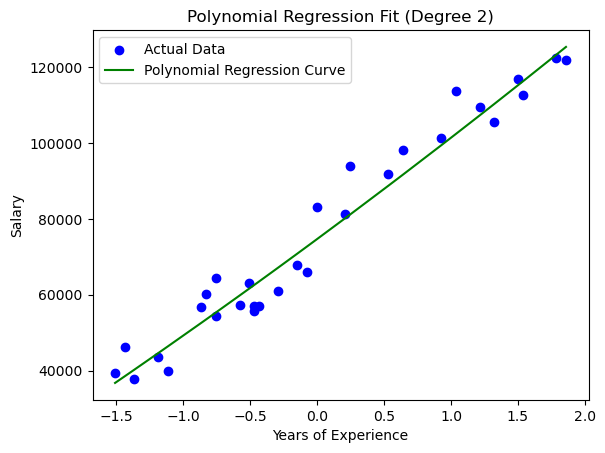

In [45]:
# Predictions for polynomial regression
y_pred_poly = poly_reg.predict(X_poly)

plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, y_pred_poly, color='green', label="Polynomial Regression Curve")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression Fit (Degree 2)")
plt.legend()
plt.show()


In [47]:
# Predictions
y_pred_lin_test = lin_reg.predict(X_test)

# Metrics
mse_lin = mean_squared_error(y_test, y_pred_lin_test)
mae_lin = mean_absolute_error(y_test, y_pred_lin_test)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin_test)


In [49]:
# Transform test set
X_poly_test_2 = poly_feat.transform(X_test)

# Predictions
y_pred_poly_test = poly_reg.predict(X_poly_test_2)

# Metrics
mse_poly = mean_squared_error(y_test, y_pred_poly_test)
mae_poly = mean_absolute_error(y_test, y_pred_poly_test)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly_test)


In [51]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [mse_lin, mse_poly],
    "MAE": [mae_lin, mae_poly],
    "RMSE": [rmse_lin, rmse_poly],
    "R2 Score": [r2_lin, r2_poly]
})

comparison


,Model,MSE,MAE,RMSE,R2 Score
0,Linear Regression,4.983010e+07,6286.453831,7059.043622,0.902446
1,Polynomial Regression,5.252792e+07,6381.371430,7247.614530,0.897165


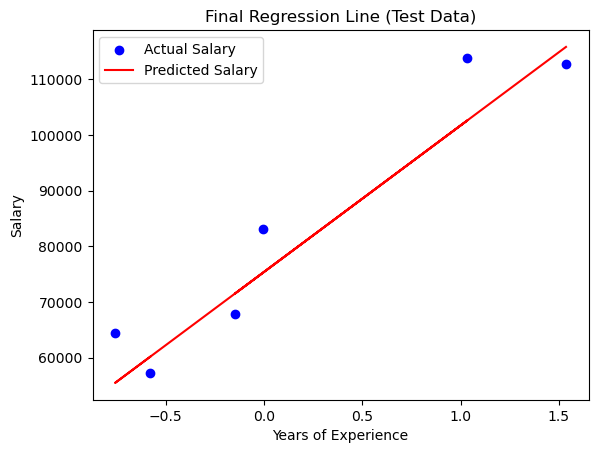

In [53]:
# Final regression line (Linear Regression)

plt.scatter(X_test, y_test, color='blue', label="Actual Salary")
plt.plot(X_test, y_pred_lin_test, color='red', label="Predicted Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Final Regression Line (Test Data)")
plt.legend()
plt.show()